# Digital Marketing Budget Allocation Under Uncertainty

## Goal

The goal of the project is to define a better policy for budget distribution for Digital Marketing advertisement sets(ad sets) on Meta Ads (Facebook/Instagram) placements aggregated in the export.
Due to the lack of purchases or revenue information the performance indicators will be two:
1. Landing Page Views(LPV)
2. Cost per LPV

<br> 

The uncertainty aspect of the project comes from the fact that there are variations of the result, which are aggregated weekly.
Instead of accurate prediction, Monte Carlo simulation with bootstrap resampling will be used in order to obtain a distribution of possible results.
In total 3 scenarios will be investigated:
- Equal distribution
- Historical average
- Risk-aware policy (maximizing the 10th percentile (P10) of LPVs or minimizing the probability that LPVs fall below a threshold)

<br>

Desired outcomes that are going to be reported for each scenario would be:
- Expected results - expected LPV and cost per LPV.
- Risk metrics(percentiles/probability of underperformance)

<br>
Practical interpretation, based on the objective of the business - "stability" or "maximizing the results"

## Data

Dataset contains Meta Ads export, on a weekly basis, for the period 01.03.2024 to 01.03.2025.

A single row in the file represents a pair Week x Ad set pair.

<br>

Key metrics that will be of interest and be used are:

- Amount spent(EUR)
- Link clicks
- Landing page views
- Impressions
- Reach
- CPC
- CPM

<br>

Campaign and ad set names are removed **Campaign ID** and **Ad set ID** will be used instead.

Main focus will be on traffic related metrics(LPV and cost per LPV) because of missing or not sufficient enough purchases/ROAS


## Metrics

### Exported metrics

1. **LPV** - Successful loading of the destination page after an ad click. [L1]
2.  **Link Cliks** - Link clicks measure the number of clicks on ad links leading to a specified destination or experience. [L2]
3.  **Impressions** - Impressions count the total number of times an advertisement is displayed. [L3]
4.  **CPM** - Cost per **1,000 impressions** [L4]
5.  **CPC** - cost per link click, derived from the equation: [L5]
$$
CPC = \cfrac{\text{Amount Spent}}{\text{Link Clicks}}
$$

### Derived metrics

1. **Cost per LPV** derivied from:
$$
\text{Cost per LPV} = \cfrac{\text{Amount Spent}}{\text{LPV}}
$$


<br>

2. **LPV rate** derived from:
$$
\text{LPV rate}= \cfrac{\text{LPV}}{\text{Link Clicks}}
$$

<br>

3. **Link CTR** derived from:
$$
\text{Link CTR} = \cfrac{\text{Link Clicks}}{\text{Impressions}}
$$

## Baseline exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:

#reading of the csv file
csv_path = "../data/Meta-report-Mar-1-2024-to-Mar-1-2025.csv"
df = pd.read_csv(csv_path)

print("shape:", df.shape)
df.head(3)

shape: (83, 29)


,Week,Objective,Campaign ID,Ad set ID,Delivery status,Delivery level,Reach,Impressions,Frequency,Attribution setting,...,Clicks (all),"CPM (cost per 1,000 impressions)",Result rate,Cost per unique link click,Ad Set Budget,Ad Set Budget Type,Campaign Budget,Campaign Budget Type,Reporting starts,Reporting ends
0,2025-02-28 - 2025-03-01,LINK_CLICKS,120220823212200002,120220823212220002,completed,adset,3885,5221,1.343887,7-day click or 1-day view,...,159,1.413522,3.179468,0.050204,Using campaign budget,NaN,72,Lifetime,2025-02-28,2025-03-01
1,2025-02-21 - 2025-02-27,LINK_CLICKS,120220823212200002,120220823212220002,completed,adset,7374,16252,2.203960,7-day click or 1-day view,...,543,1.675486,4.024120,0.059325,Using campaign budget,NaN,72,Lifetime,2025-02-21,2025-02-27
2,2025-02-14 - 2025-02-20,LINK_CLICKS,120220823212200002,120220823212220002,completed,adset,3564,4504,1.263749,7-day click or 1-day view,...,165,1.307726,3.263766,0.045659,Using campaign budget,NaN,72,Lifetime,2025-02-14,2025-02-20


In [3]:
#Converting data types of collumns with Campaign and Ad set IDs as to avoid scientific notation issues
df["Campaign ID"] = df["Campaign ID"].astype("Int64").astype(str)
df["Ad set ID"] = df["Ad set ID"].astype("Int64").astype(str)
#Managing and cinvertin str data to dates for better parsing afterwards
week_split = df["Week"].str.split(" - ", expand=True)
df["week_start"] = pd.to_datetime(week_split[0], errors="coerce")
df["week_end"] = pd.to_datetime(week_split[1], errors="coerce")

In [4]:

#Computing the three desired "Derived Metrics" in order to proceed with policy evaluation later(safe division; NaN if the denominator is 0)
df["cost_per_lpv"] = np.where(df["Landing page views"] > 0,
                              df["Amount spent (EUR)"] / df["Landing page views"],
                              np.nan)

df["lpv_rate"] = np.where(df["Link clicks"] > 0,
                              df["Landing page views"] / df["Link clicks"],
                              np.nan)

df["link_ctr"] = np.where(df["Impressions"] > 0,
                              df["Link clicks"] / df["Impressions"],
                              np.nan)

df[["cost_per_lpv","lpv_rate","link_ctr"]].describe()

,cost_per_lpv,lpv_rate,link_ctr
count,69.000000,69.000000,76.000000
mean,1.086531,0.452634,0.021959
std,5.681558,0.242885,0.017771
min,0.054923,0.007380,0.000224
25%,0.140963,0.269231,0.008497
50%,0.218571,0.470000,0.017084
75%,0.346250,0.594340,0.034652
max,47.290000,0.964706,0.077851


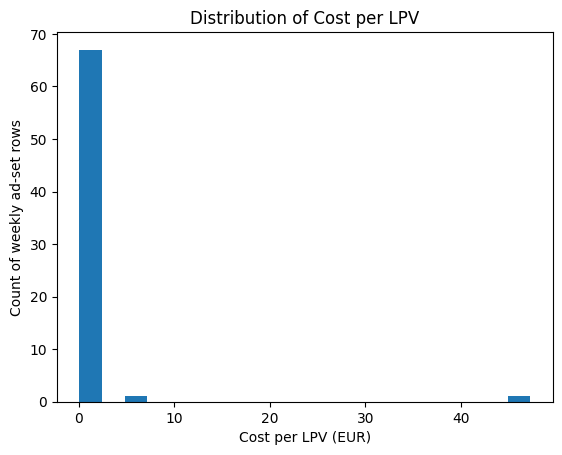

In [5]:

plt.figure()
plt.hist(df["cost_per_lpv"].dropna(), bins=20)
plt.xlabel("Cost per LPV (EUR)")
plt.ylabel("Count of weekly ad-set rows")
plt.title("Distribution of Cost per LPV")
plt.show()

1- Out of 83 weekly ad-set rows, 14 have cost_per_lpv and lpv_rate as NaN due to zero/missing denominators; link_ctr has 7 NaNs due to zero/missing impressions.
<br>
2- The distribution of cost per LPV is strongly right-skewed: median $\approx$ 0.22 EUR, but a small number of weeks have very high values (max ≈ 47.29 EUR).
<br>
3- Because of the long tail/outliers, risk-aware evaluation (percentiles / probability of underperformance) is more informative than only comparing averages.
<br>
4- To improve readability (since a single extreme outlier stretches the x-axis), I also include an additional histogram with the cost_per_lpv values clipped to a reasonable upper bound, so the main body of the distribution is visible.

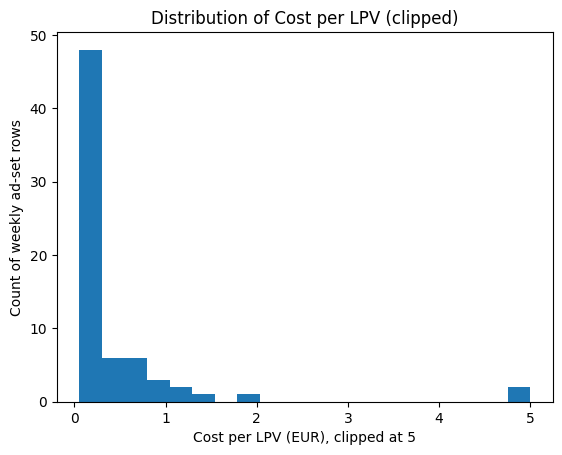

In [6]:
plt.figure()
plt.hist(df["cost_per_lpv"].dropna().clip(upper=5), bins=20)
plt.xlabel("Cost per LPV (EUR), clipped at 5")
plt.ylabel("Count of weekly ad-set rows")
plt.title("Distribution of Cost per LPV (clipped)")
plt.show()

1- Majority of the data is close to 0, even after clipping it is still right-skewed[L6]
<br>
2- Higher cost per LPV indicates lower efficiency (more spend per landing page view), so high values are candidates for underperformance investigation.[L7]

In [7]:
# Weekly totals for spend (EUR) and LPV

weekly = (df.groupby("week_start", as_index=False).agg(total_spend_eur=("Amount spent (EUR)", "sum"),
                                                       total_lpv=("Landing page views", "sum"),
                                                       rows=("week_start", "size")).sort_values("week_start"))
weekly.head()

,week_start,total_spend_eur,total_lpv,rows
0,2024-03-01,7.23,121.0,1
1,2024-03-08,3.57,65.0,1
2,2024-03-22,0.10,0.0,1
3,2024-03-29,13.47,142.0,3
4,2024-04-05,51.39,301.0,4


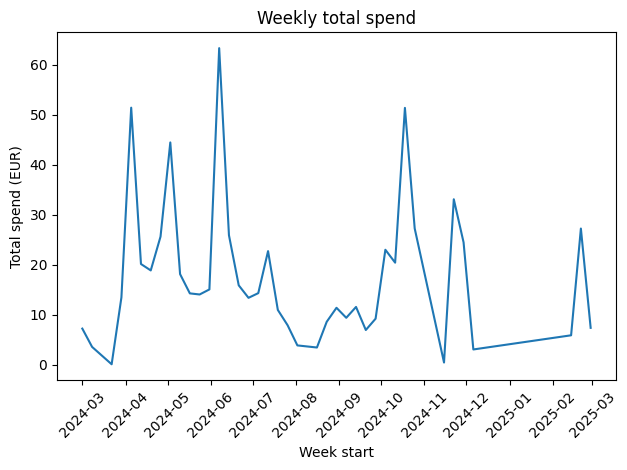

In [8]:
# 

plt.figure()
plt.plot(weekly["week_start"], weekly["total_spend_eur"])
plt.xlabel("Week start")
plt.ylabel("Total spend (EUR)")
plt.title("Weekly total spend")
# To keep the x-axis date labels readable, show one tick per month and format it as YYYY-MM and a rotation of 45 degrees was made
ax = plt.gca()                                            
ax.xaxis.set_major_locator(mdates.MonthLocator())         
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1- Spend is uneven over time (spend is concentrated in specific periods), which may reflect campaign scheduling and/or seasonality effects.[L8]
<br>
2- Because of the aforementioned point, it is needed to further analyze the relation risk/distribution(averages can mislead under skewness)[L9]

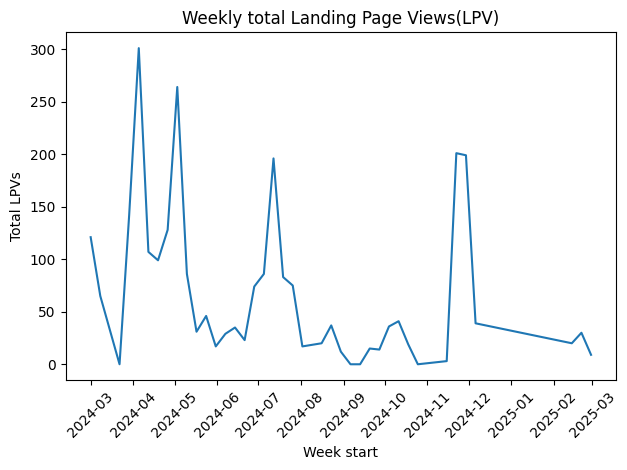

In [9]:
plt.figure()
plt.plot(weekly["week_start"], weekly["total_lpv"])
plt.xlabel("Week start")
plt.ylabel("Total LPVs")
plt.title("Weekly total Landing Page Views(LPV)")
# the same formatting rules are applied as in the graph above for better readability 
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

1- LPV is with high variability
<br>
2- Peaks are not evenly distributed over time; this pattern is consistent with campaign-based activity and/or seasonality effects [L10]
<br>
3- Combined with the "Weekly total spend" graph a further analysis is possible and needed - in order to search for a relation between increase in spend and LPV peaks

In [10]:
# Outlier inspection: best vs worst weeks by cost_per_lpv
# Identify which Week × Ad set rows are the most/least efficient in terms of spend per LPV

cols = ["week_start", "week_end",
        "Campaign ID", "Ad set ID",
        "Amount spent (EUR)", "Link clicks", "Landing page views",
        "cost_per_lpv", "lpv_rate", "link_ctr"]
# Sort by cost_per_lpv descending to find the least efficient rows (highest EUR per LPV)
top10 = df.sort_values("cost_per_lpv", ascending=False)[cols].head(10)

# Sort by cost_per_lpv ascending to find the most efficient rows (lowest EUR per LPV)
bottom10 = df.sort_values("cost_per_lpv", ascending=True)[cols].head(10)

# Display both tables so we can compare extreme cases and decide how to treat outliers later
top10, bottom10 

(   week_start   week_end         Campaign ID           Ad set ID  \
 13 2024-10-18 2024-10-24  120216036283800002  120216036283850002   
 45 2024-06-07 2024-06-13  120212179890370002  120212179890390002   
 32 2024-07-19 2024-07-25  120213078877750002  120213078877730002   
 42 2024-06-14 2024-06-20  120212179890370002  120212179890390002   
 16 2024-10-04 2024-10-10  120215665844180002  120215665844200002   
 49 2024-05-31 2024-06-06  120212052752840002  120212052752930002   
 1  2025-02-21 2025-02-27  120220823212200002  120220823212220002   
 44 2024-06-14 2024-06-20  120212052752840002  120212052752930002   
 0  2025-02-28 2025-03-01  120220823212200002  120220823212220002   
 46 2024-06-07 2024-06-13  120212052752840002  120212052752930002   
 
     Amount spent (EUR)  Link clicks  Landing page views  cost_per_lpv  \
 13               47.29         10.0                 1.0     47.290000   
 45               49.22         32.0                10.0      4.922000   
 32              

In [11]:
# For better readability, an extraction and display the Top/Bottom 10 rows by cost_per_lpv is made.

top10 = df.sort_values("cost_per_lpv", ascending=False)[cols].head(10)
bottom10 = df.sort_values("cost_per_lpv", ascending=True)[cols].head(10)

In [12]:
# Display settings (formatting only; does not change data)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 30)

top10_display = top10.copy()
bottom10_display = bottom10.copy()

for t in (top10_display, bottom10_display):
    t["Amount spent (EUR)"] = t["Amount spent (EUR)"].round(2)
    t["cost_per_lpv"] = t["cost_per_lpv"].round(3)
    t["lpv_rate"] = t["lpv_rate"].round(3)
    t["link_ctr"] = t["link_ctr"].round(4)

print("Top 10 worst rows by cost_per_lpv")
display(top10_display)

print("Top 10 best rows by cost_per_lpv")
display(bottom10_display)

Top 10 worst rows by cost_per_lpv


,week_start,week_end,Campaign ID,Ad set ID,Amount spent (EUR),Link clicks,Landing page views,cost_per_lpv,lpv_rate,link_ctr
13,2024-10-18,2024-10-24,120216036283800002,120216036283850002,47.29,10.0,1.0,47.290,0.100,0.0015
45,2024-06-07,2024-06-13,120212179890370002,120212179890390002,49.22,32.0,10.0,4.922,0.312,0.0050
32,2024-07-19,2024-07-25,120213078877750002,120213078877730002,3.98,271.0,2.0,1.990,0.007,0.0779
42,2024-06-14,2024-06-20,120212179890370002,120212179890390002,13.47,24.0,10.0,1.347,0.417,0.0105
16,2024-10-04,2024-10-10,120215665844180002,120215665844200002,14.68,40.0,12.0,1.223,0.300,0.0158
49,2024-05-31,2024-06-06,120212052752840002,120212052752930002,12.23,100.0,11.0,1.112,0.110,0.0472
1,2025-02-21,2025-02-27,120220823212200002,120220823212220002,27.23,654.0,30.0,0.908,0.046,0.0402
44,2024-06-14,2024-06-20,120212052752840002,120212052752930002,7.61,68.0,9.0,0.846,0.132,0.0344
0,2025-02-28,2025-03-01,120220823212200002,120220823212220002,7.38,166.0,9.0,0.820,0.054,0.0318
46,2024-06-07,2024-06-13,120212052752840002,120212052752930002,14.07,145.0,19.0,0.741,0.131,0.0483


Top 10 best rows by cost_per_lpv


,week_start,week_end,Campaign ID,Ad set ID,Amount spent (EUR),Link clicks,Landing page views,cost_per_lpv,lpv_rate,link_ctr
81,2024-03-08,2024-03-14,120207878299510002,120207878299500002,3.57,74.0,65.0,0.055,0.878,0.0418
82,2024-03-01,2024-03-07,120207878299510002,120207878299500002,7.23,139.0,121.0,0.060,0.871,0.0387
3,2024-12-06,2024-12-12,120217403071690002,120217403072650002,3.06,63.0,39.0,0.078,0.619,0.0609
77,2024-03-29,2024-04-04,120209477171000002,120209477171010002,10.69,143.0,126.0,0.085,0.881,0.0354
73,2024-04-05,2024-04-11,120209477171000002,120209477171010002,4.21,60.0,49.0,0.086,0.817,0.0356
31,2024-07-19,2024-07-25,120213078826680002,120213078826740002,6.98,112.0,81.0,0.086,0.723,0.0356
33,2024-07-12,2024-07-18,120212854744540002,120212854744650002,1.59,24.0,17.0,0.094,0.708,0.0295
30,2024-07-26,2024-08-01,120213078826680002,120213078826740002,6.00,106.0,63.0,0.095,0.594,0.0431
39,2024-06-28,2024-07-04,120212854744540002,120212854744650002,4.07,80.0,41.0,0.099,0.512,0.0460
34,2024-07-12,2024-07-18,120213078826680002,120213078826740002,7.00,106.0,62.0,0.113,0.585,0.0287


Outlier inspection (cost_per_lpv extremes), reasons for initiating this step:

1- It ranks Week x Ad set rows, by cost_per_lpv to identify the least efficiant and most efficient observations in the current dataset.
<br>
2- Because of the right-skewed data for cost_per_lpv the averages on the their own can be misleading without understanding the extremes.[L11]
<br>
3- The top10 table highlights rows, where spend per LPV is unusually high (often coincides with very low LPV counts), which can dominate distribution-based analysis.[L12]
<br>
4- The bottom10 table actually provides a clue as to what a good performing ad set from the current dataset looks like.
<br>
5- By inspecting both extremes together (including: Amount spent, Link clicks, Landing page views, and lpv_rate/link_ctr) we gain the posibility to:
    validate that the derived metrics behave as expected
    decide a transparent outlier treatment policy for the Monte Carlo stage[L13]
<br>
A documented rationale for how outliers will be handled in order to have later policy comparisons to be fair and reproducible is the desired outcome of this step

In [13]:
# Exclude a single extreme row identified as human/operational error (max cost_per_lpv)

idx_error = df["cost_per_lpv"].idxmax()

# keep it for documentation/traceability
error_row = df.loc[idx_error]                    


# dataset to be used in Monte Carlo simulations
df_sim = df.drop(index=idx_error).copy()         

print("Excluded row index:", idx_error)
display(error_row[["week_start","Campaign ID","Ad set ID","Amount spent (EUR)","Landing page views","cost_per_lpv"]])

print("Original rows:", len(df), "| Simulation rows:", len(df_sim))

Excluded row index: 13


week_start            2024-10-18 00:00:00
Campaign ID            120216036283800002
Ad set ID              120216036283850002
Amount spent (EUR)                  47.29
Landing page views                    1.0
cost_per_lpv                        47.29
Name: 13, dtype: object

Original rows: 83 | Simulation rows: 82


1- One extreme row had LPV=1 and cost_per_lpv $\approx$ 47.29 EUR, which was identified as likely operational/human error.
<br>
2- Because Monte Carlo simulation is intended to model process uncertainty (not data-entry mistakes),only one single row was excluded from the input[L14]
<br>
3- Original dataset was kept unchanged and a new one for simulation purposes- df_sim was created, in order to have transparency and reproducable behaviour
<br>
4- Excluded row is displayed in this notebook for tracebility

## Next steps

## Limitations & Assumptions

One extreme observation (cost_per_lpv $\approx$ 47.29 EUR) corresponds to LPV = 1 and was treated as an outlier likely caused by human error during settings management period of the ad set, therefore it will be excluded from the simulation to avoid distorting results.

## References

[L1] Meta Business Help Center - Landing Page Views - [Link](https://www.facebook.com/business/help/417293491972212?id=561906377587030)
<br>
[L2] Meta Business Help Center - Link clicks - [Link](https://www.facebook.com/business/help/284415655604125?id=354406972049255)
<br>
[L3] Meta Business Help Center - Impressions - [Link](https://www.facebook.com/business/help/675615482516035)
<br>
[L4] Meta Business Help Center - CPM - [Link](https://www.facebook.com/business/help/753932008002620?helpref=faq_content)
<br>
[L5] Meta Business Help Center - CPC (cost per link click) -  [Link](https://www.facebook.com/business/help/683065845109838?locale=bg_BG)
<br>
[L6] Skewness/mean sensitive to outliers (why percentiles help) - [Link](https://statisticsbyjim.com/basics/skewed-distribution/?utm_source=chatgpt.com)
<br>
[L7] Clipping/outliers handling (why clipped histogram is OK) - [Link](https://medium.com/life-at-hopper/clip-it-clip-it-good-1f1bf711b291)
<br>
[L8] Meta: cost per result is spend/results (supports “higher cost = less efficient”) - [Link](https://www.facebook.com/business/help/305102563866933?utm_source=chatgpt.com)
<br>
[L9] Seasonality affects demand/marketing patterns (use “may reflect”) - [Link](https://amplitude.com/explore/experiment/data-winsorization?utm_source=chatgpt.com)
<br>
[L10] Apparel goods are seasonal; timing matters (more academic) - [Link](https://www.investopedia.com/terms/s/seasonality.asp?utm_source=chatgpt.com)
<br>
[L11] Skewness/outliers: OpenStax - [Link](https://openstax.org/books/introductory-business-statistics-2e/pages/2-6-skewness-and-the-mean-median-and-mode?utm_source=chatgpt.com)
<br>
[L12] Seasonality definition - [Link](https://en.wikipedia.org/wiki/Seasonality?utm_source=chatgpt.com)
<br>
[L13] Monte Carlo definition - [Link](https://www.ibm.com/think/topics/monte-carlo-simulation?utm_source=chatgpt.com)
<br>
[L14] Monte Carlo definition - [Link](https://www.ibm.com/think/topics/monte-carlo-simulation?utm_source=chatgpt.com)